In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [3]:
# Datensatz wird geladen und die erste Zeile angezeigt

df = pd.read_csv("../data/raw/autoinsurance_churn.csv")

df.head()


,individual_id,address_id,curr_ann_amt,days_tenure,cust_orig_date,age_in_years,date_of_birth,latitude,longitude,city,state,county,income,has_children,length_of_residence,marital_status,home_market_value,home_owner,college_degree,good_credit,acct_suspd_date,Churn
0,2.213000e+11,5.213000e+11,818.877997,1454.0,2018-12-09,44,1978-06-23,32.578829,-96.305006,Kaufman,TX,Kaufman,22500.0,1.0,15.0,Married,50000 - 74999,1.0,1.0,1.0,NaN,0
1,2.213001e+11,5.213001e+11,974.199182,1795.0,2018-01-02,72,1950-05-30,32.732209,-97.000893,Grand Prairie,TX,Dallas,27500.0,0.0,2.0,Single,50000 - 74999,1.0,0.0,0.0,NaN,0
2,2.213007e+11,5.213002e+11,967.375112,4818.0,2009-09-23,55,1967-07-07,32.819777,-96.846938,Dallas,TX,Dallas,42500.0,0.0,10.0,Married,75000 - 99999,1.0,0.0,0.0,NaN,0
3,2.213016e+11,5.213006e+11,992.409561,130.0,2022-07-25,53,1969-05-25,32.684065,-97.162180,Arlington,TX,Tarrant,125000.0,1.0,6.0,Married,175000 - 199999,1.0,0.0,1.0,2021-12-22,1
4,2.213016e+11,5.213006e+11,784.633494,5896.0,2006-10-11,50,1972-09-25,32.751398,-97.376745,Fort Worth,TX,Tarrant,87500.0,1.0,4.0,Married,225000 - 249999,1.0,1.0,1.0,NaN,0


In [4]:
# Datensatz analysieren wie fehlende Werte, Spalten analysieren, Datentypen untersuchen usw.

print(df.shape)
df.info()
df.describe()




(1680909, 22)
<class 'pandas.DataFrame'>
RangeIndex: 1680909 entries, 0 to 1680908
Data columns (total 22 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   individual_id        1680909 non-null  float64
 1   address_id           1680909 non-null  float64
 2   curr_ann_amt         1680909 non-null  float64
 3   days_tenure          1680909 non-null  float64
 4   cust_orig_date       1680909 non-null  str    
 5   age_in_years         1680909 non-null  int64  
 6   date_of_birth        1680909 non-null  str    
 7   latitude             1427190 non-null  float64
 8   longitude            1427190 non-null  float64
 9   city                 1668842 non-null  str    
 10  state                1680909 non-null  str    
 11  county               1668842 non-null  str    
 12  income               1680909 non-null  float64
 13  has_children         1680909 non-null  float64
 14  length_of_residence  1680909 non-null  float64


,individual_id,address_id,curr_ann_amt,days_tenure,age_in_years,latitude,longitude,income,has_children,length_of_residence,home_owner,college_degree,good_credit,Churn
count,1.680909e+06,1.680909e+06,1.680909e+06,1.680909e+06,1.680909e+06,1.427190e+06,1.427190e+06,1.680909e+06,1.680909e+06,1.680909e+06,1.680909e+06,1.680909e+06,1.680909e+06,1.680909e+06
mean,2.213018e+11,5.213007e+11,9.403140e+02,3.602007e+03,5.581648e+01,3.285130e+01,-9.694764e+01,8.149773e+04,5.221336e-01,7.501612e+00,8.201003e-01,3.515033e-01,8.411937e-01,1.150901e-01
std,9.926327e+05,4.174711e+05,2.465392e+02,2.341005e+03,1.455192e+01,1.944458e-01,2.963725e-01,5.438100e+04,4.995100e-01,5.135309e+00,3.841040e-01,4.774399e-01,3.654955e-01,3.191308e-01
min,2.213000e+11,5.213000e+11,-1.943131e+02,2.000000e+01,2.300000e+01,3.199061e+01,-9.802223e+01,5.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.213009e+11,5.213003e+11,7.721025e+02,1.398000e+03,4.500000e+01,3.271247e+01,-9.716765e+01,4.750000e+04,0.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
50%,2.213018e+11,5.213007e+11,9.350098e+02,3.651000e+03,5.500000e+01,3.284678e+01,-9.690326e+01,7.000000e+04,1.000000e+00,6.801000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,2.213027e+11,5.213010e+11,1.102992e+03,6.291000e+03,6.400000e+01,3.298491e+01,-9.672065e+01,8.750000e+04,1.000000e+00,1.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
max,2.213033e+11,5.213015e+11,2.269374e+03,6.291000e+03,1.140000e+02,3.354658e+01,-9.607035e+01,2.500000e+05,1.000000e+00,1.500000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [5]:
# Missing values and percentage by missing values

missing = df.isnull().sum()
missing.sort_values(ascending=False)

missing_percent = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
missing_percent

acct_suspd_date        88.490989
latitude               15.094154
longitude              15.094154
home_market_value       5.490244
county                  0.717885
city                    0.717885
age_in_years            0.000000
cust_orig_date          0.000000
days_tenure             0.000000
curr_ann_amt            0.000000
address_id              0.000000
individual_id           0.000000
date_of_birth           0.000000
state                   0.000000
has_children            0.000000
income                  0.000000
marital_status          0.000000
length_of_residence     0.000000
home_owner              0.000000
college_degree          0.000000
good_credit             0.000000
Churn                   0.000000
dtype: float64

In [6]:
# Copy the Dataframe and percentage by Churn value counts

df_clean = df.copy()

df_clean = df_clean.drop(columns=["acct_suspd_date"])

df_clean.columns 

df_clean["Churn"].value_counts()

df_clean["Churn"].value_counts(normalize=True)*100


Churn
0    88.490989
1    11.509011
Name: proportion, dtype: float64

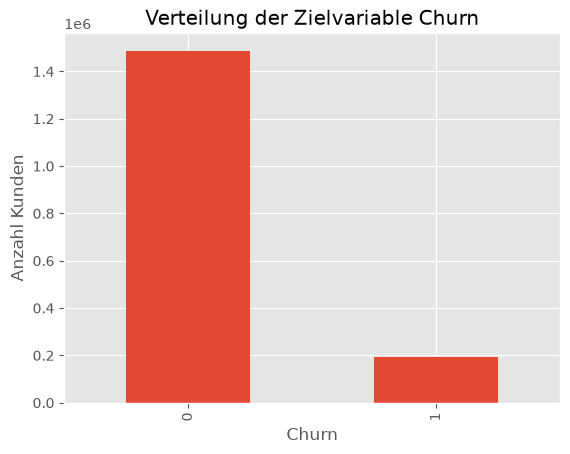

In [7]:
# Distribution by target variable Chrun

df_clean["Churn"].value_counts().plot(
    kind="bar",
    title="Verteilung der Zielvariable Churn"
)

plt.xlabel("Churn")
plt.ylabel("Anzahl Kunden")
plt.show()


In [8]:
# Select the numerical features

numerical_features = [
    "age_in_years",
    "income",
    "curr_ann_amt",
    "days_tenure",
    "length_of_residence"

]

df_clean[numerical_features].describe().round(2)

,age_in_years,income,curr_ann_amt,days_tenure,length_of_residence
count,1680909.00,1680909.00,1680909.00,1680909.00,1680909.00
mean,55.82,81497.73,940.31,3602.01,7.50
std,14.55,54381.00,246.54,2341.00,5.14
min,23.00,5000.00,-194.31,20.00,0.00
25%,45.00,47500.00,772.10,1398.00,3.00
50%,55.00,70000.00,935.01,3651.00,6.80
75%,64.00,87500.00,1102.99,6291.00,13.00
max,114.00,250000.00,2269.37,6291.00,15.00


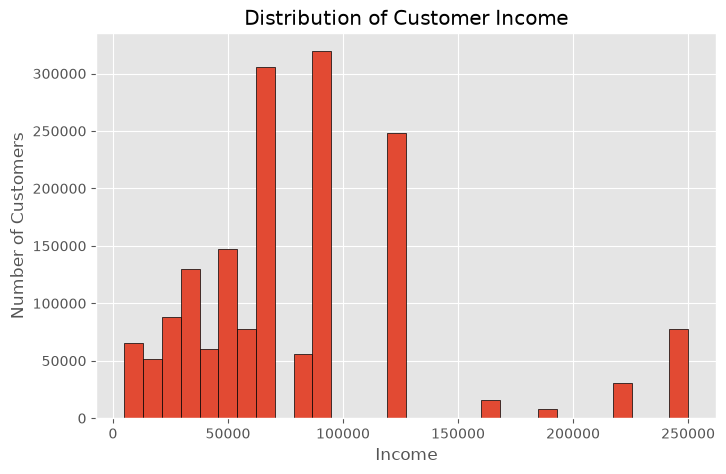

In [9]:
# Visualize the Distribution of Customer Income 

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["income"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()


In [10]:
# Compare the variables in groups

df_clean.groupby("Churn")[numerical_features].mean().round(2)


,age_in_years,income,curr_ann_amt,days_tenure,length_of_residence
Churn,,,,,
0,56.11,81616.01,938.70,3778.32,7.57
1,53.59,80588.33,952.74,2246.39,7.00


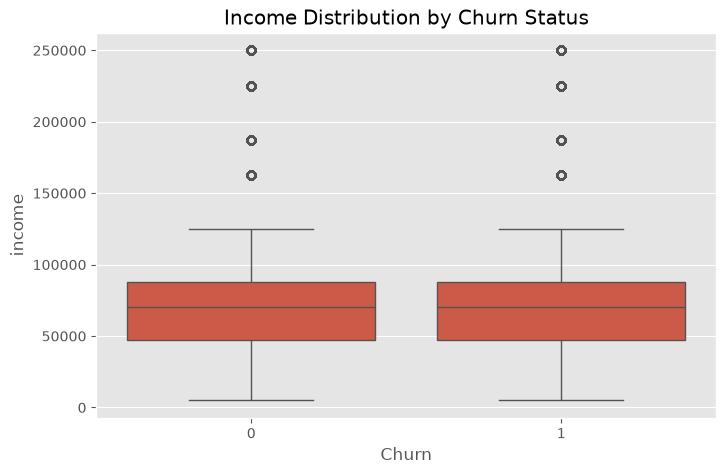

In [11]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="income"
)

plt.title("Income Distribution by Churn Status")

plt.show()


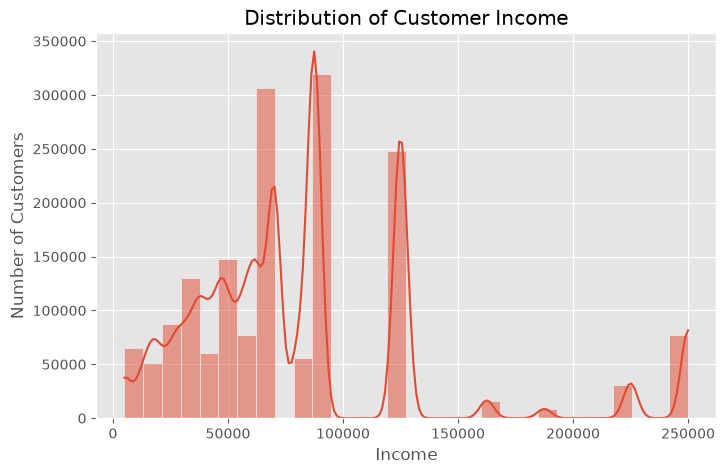

In [12]:
# Distribution of Customer Income

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="income",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()


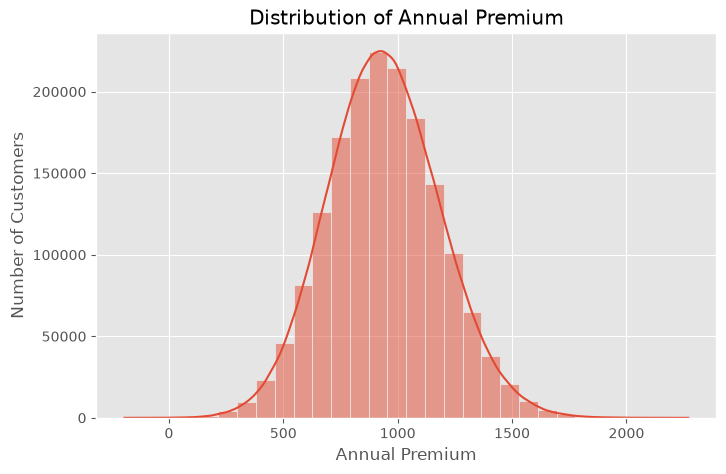

In [13]:
# Visualize the annual insurance premium of customers

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="curr_ann_amt",
    bins=30,
    kde=True
)

plt.title("Distribution of Annual Premium")
plt.xlabel("Annual Premium")
plt.ylabel("Number of Customers")

plt.show()


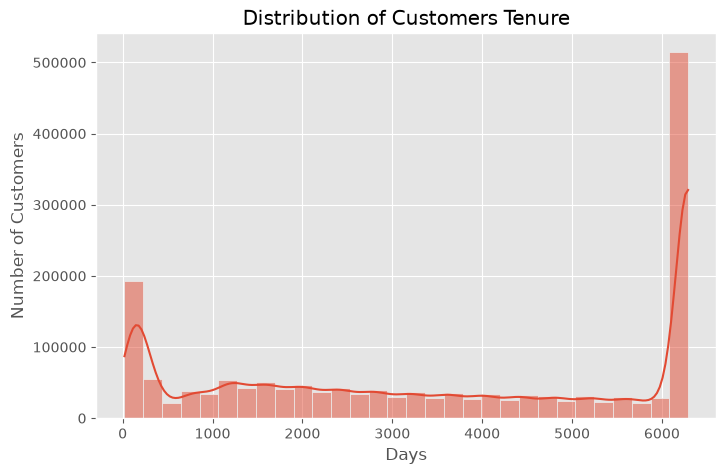

In [14]:
# Visualize how long customers have been with the company

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="days_tenure",
    bins=30,
    kde=True
)

plt.title("Distribution of Customers Tenure")
plt.xlabel("Days")
plt.ylabel("Number of Customers")

plt.show()


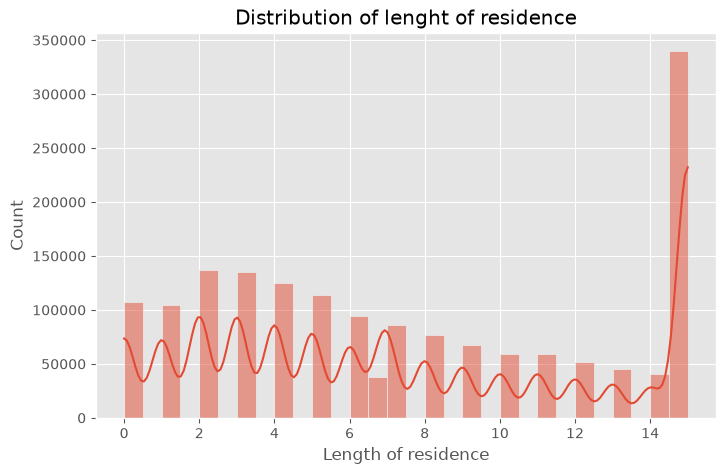

In [15]:
# Documentation
# Purpose:
# This visualization examines the distribution of the
# 'length_of_residence' feature to identify its shape,
# spread, and potential outliers.

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="length_of_residence",
    bins=30,
    kde=True
)

plt.title("Distribution of lenght of residence")
plt.xlabel("Length of residence")
plt.ylabel("Count")

plt.show()



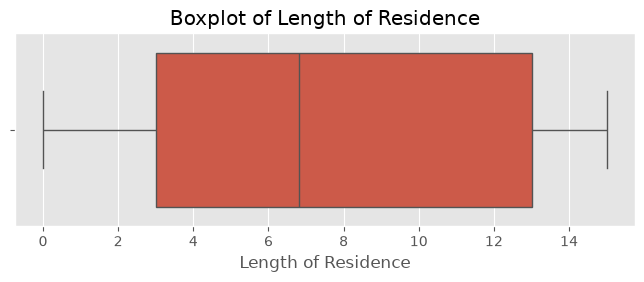

In [16]:
# Visualize the distribution and detect potential outliers
# using a boxplot for the 'length_of_residence' feature.
plt.figure(figsize=(8,2.5))

sns.boxplot(x=df_clean["length_of_residence"])

plt.title("Boxplot of Length of Residence")
plt.xlabel("Length of Residence")

plt.show()

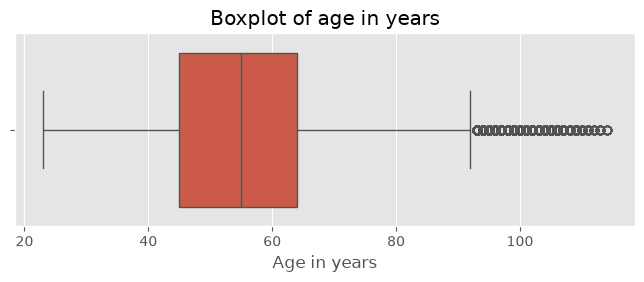

In [17]:
# Using a boxplot for the "age_in_years" feature

plt.figure(figsize=(8,2.5))

sns.boxplot(x=df_clean["age_in_years"])

plt.title("Boxplot of age in years")
plt.xlabel("Age in years")

plt.show()


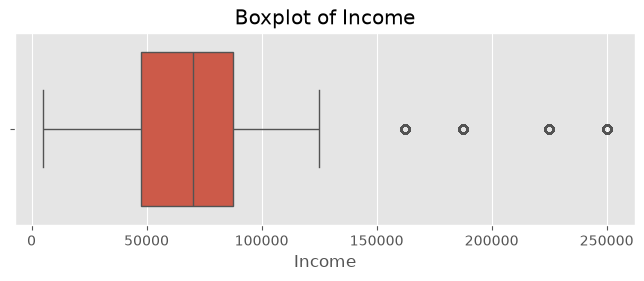

In [18]:
# Using a boxplot for the income feature

plt.figure(figsize=(8,2.5))

sns.boxplot(x=df_clean["income"])

plt.title("Boxplot of Income")
plt.xlabel("Income")

plt.show()


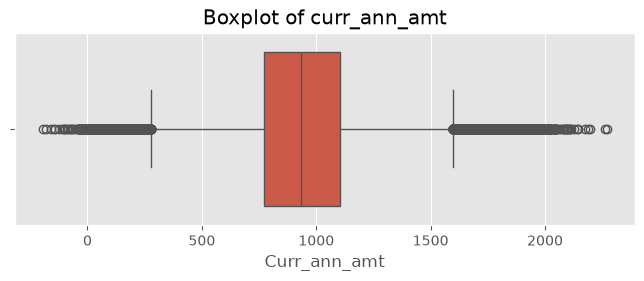

In [19]:
# Using a boxplot for the curr_ann_amt

plt.figure(figsize=(8,2.5))

sns.boxplot(x=df_clean["curr_ann_amt"])

plt.title("Boxplot of curr_ann_amt")
plt.xlabel("Curr_ann_amt")

plt.show()


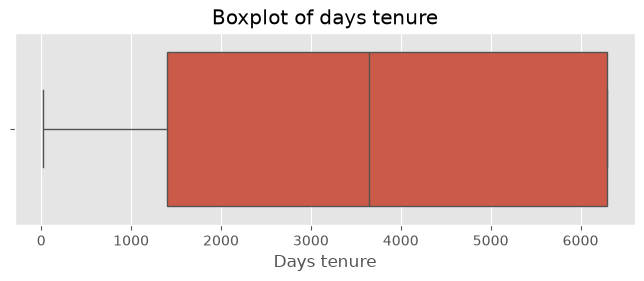

In [20]:
# Using a boxplot for the days tenure

plt.figure(figsize=(8,2.5))

sns.boxplot(x=df_clean["days_tenure"])

plt.title("Boxplot of days tenure")
plt.xlabel("Days tenure")

plt.show()


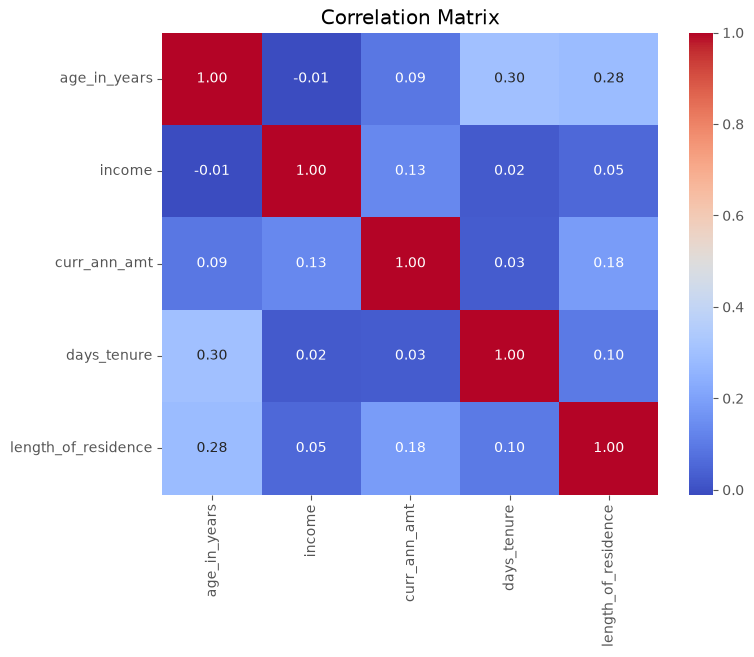

In [21]:
# Compute and visualize the correlation matrix
# to identify relationships between numerical features

plt.figure(figsize=(8,6))

correlation = df_clean[numerical_features].corr()

sns.heatmap(
    correlation, 
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()


In [22]:
# Define all categorical features for further exploratory analysis.
# These features will be analyzed individually to understand
# their distribution and relationship with the target variable.

categorical_features = [
    "marital_status",
    "home_owner",
    "college_degree",
    "good_credit",
    "state"
]


# Analyze the distribution of the 'marital_status' feature.
# This helps identify the frequency of each category
# and detect possible class imbalance.

df_clean["marital_status"].value_counts()

df_clean["marital_status"].value_counts(normalize=True).mul(100).round(2)



marital_status
Married    62.37
Single     37.63
Name: proportion, dtype: float64

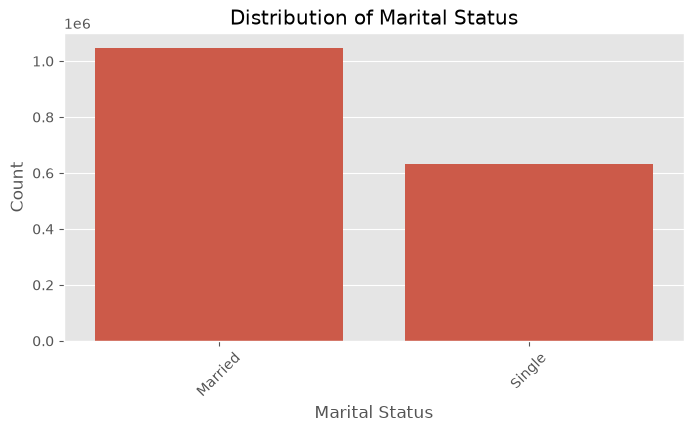

In [23]:
# Visualize the distribution of marital status
# using a count plot.

plt.figure(figsize=(8, 4))

sns.countplot(
    data=df_clean,
    x="marital_status"
)

plt.title("Distribution of Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


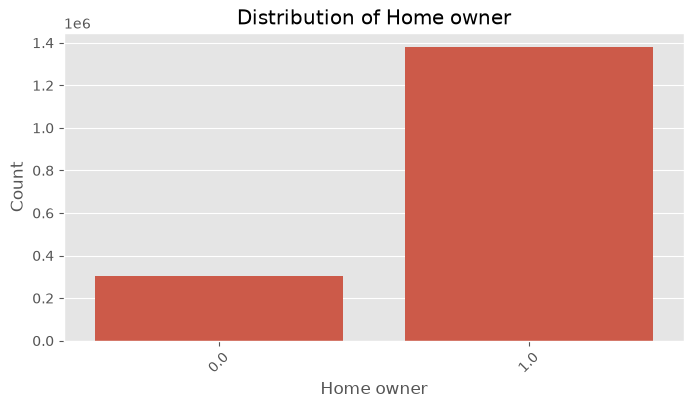

In [24]:
# Analyze the distribution of the "home_owner" feature

df_clean["home_owner"].value_counts()

(
    df_clean["home_owner"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(8, 4))

sns.countplot(
    data=df_clean,
    x="home_owner"
)

plt.title("Distribution of Home owner")
plt.xlabel("Home owner")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()



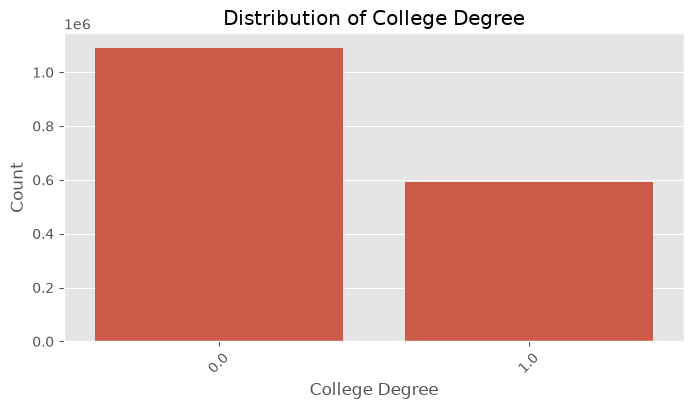

In [25]:
# Analyze and visualize the distribution of College degree

df_clean["college_degree"].value_counts()

(
    df_clean["college_degree"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(8, 4))

sns.countplot(
    data=df_clean,
    x="college_degree"
)

plt.title("Distribution of College Degree")
plt.xlabel("College Degree")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


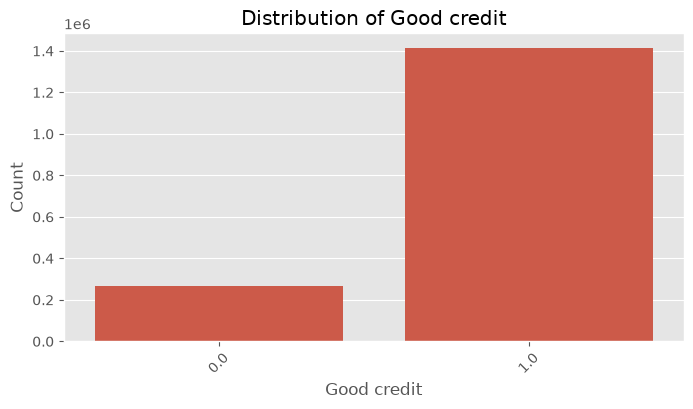

In [26]:
# Analyze and visualize the distribution of Good credit

df_clean["good_credit"].value_counts()

(
    df_clean["good_credit"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(8, 4))

sns.countplot(
    data=df_clean,
    x="good_credit"
)

plt.title("Distribution of Good credit")
plt.xlabel("Good credit")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


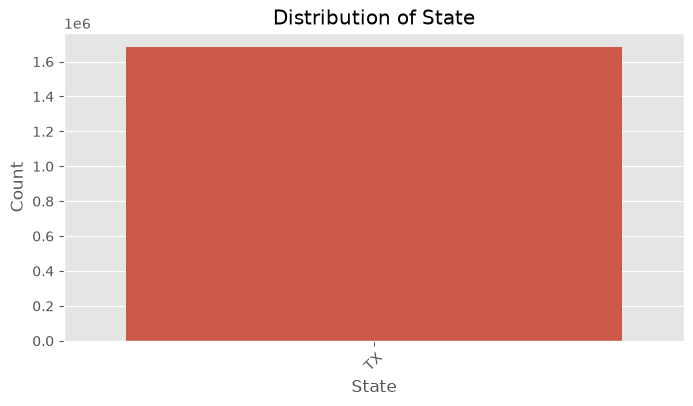

In [27]:
# Analyze and visualize the distribution of state 

df_clean["state"].value_counts()

(
    df_clean["state"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(8, 4))

sns.countplot(
    data=df_clean,
    x="state"
)

plt.title("Distribution of State")
plt.xlabel("State")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


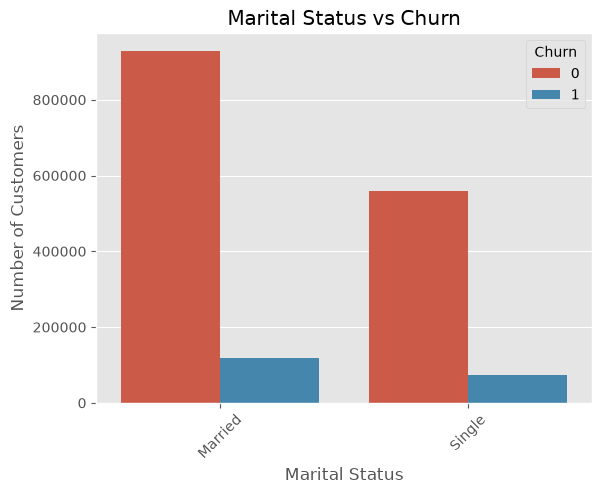

In [28]:
# Analyze the target variable

sns.countplot(
    data=df_clean,
    x="marital_status",
    hue="Churn"
)

plt.title("Marital Status vs Churn")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()



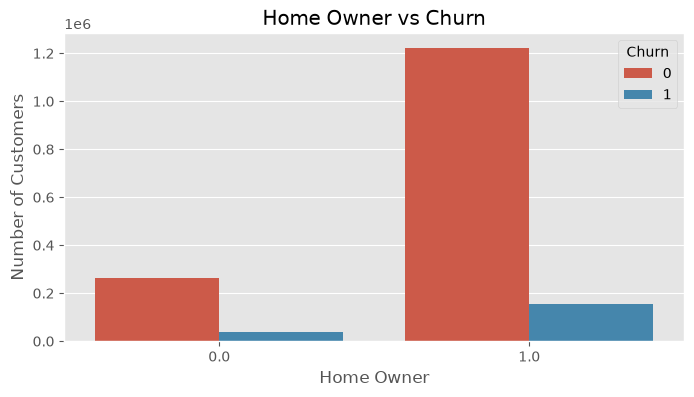

In [29]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df_clean,
    x="home_owner",
    hue="Churn"
)

plt.title("Home Owner vs Churn")
plt.xlabel("Home Owner")
plt.ylabel("Number of Customers")

plt.show()


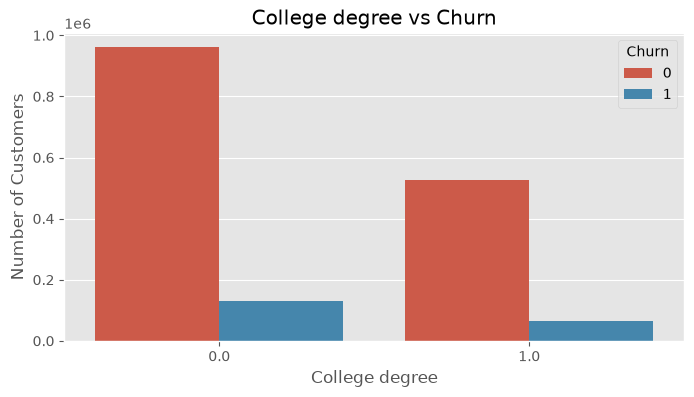

In [30]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df_clean,
    x="college_degree",
    hue="Churn"
)

plt.title("College degree vs Churn")
plt.xlabel("College degree")
plt.ylabel("Number of Customers")

plt.show()

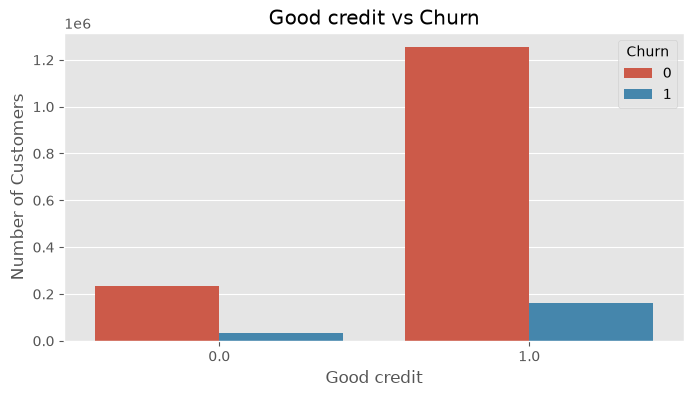

In [31]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df_clean,
    x="good_credit",
    hue="Churn"
)

plt.title("Good credit vs Churn")
plt.xlabel("Good credit")
plt.ylabel("Number of Customers")

plt.show()

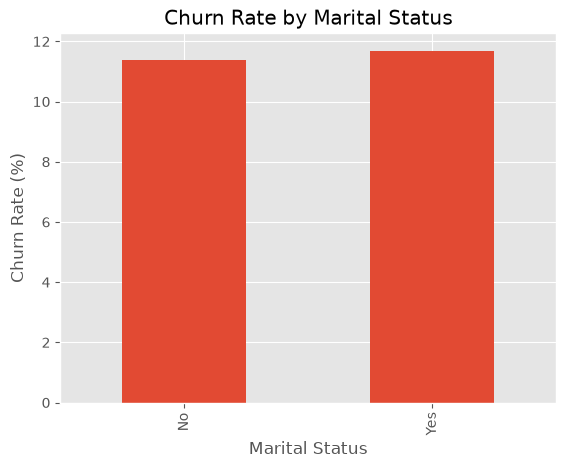

In [32]:
# Calculate the churn rate for each category.
# This provides a normalized comparison by showing
# the percentage of customers who churned within
# each category instead of absolute counts.

(
    df_clean
    .groupby("marital_status")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

(
    df_clean
    .groupby("marital_status")["Churn"]
    .mean()
    .mul(100)
    .plot(kind="bar")
)

plt.title("Churn Rate by Marital Status")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Marital Status")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()


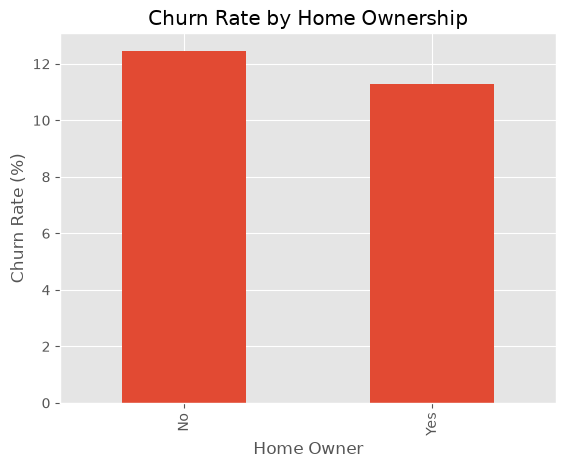

In [33]:
# Calculate and visualize the churn rate for home ownership.
# This normalized metric shows the percentage of customers
# who churned within each home ownership category.

(
    df_clean
    .groupby("home_owner")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

(
    df_clean
    .groupby("home_owner")["Churn"]
    .mean()
    .mul(100)
    .plot(kind="bar")
)

plt.title("Churn Rate by Home Ownership")
plt.xlabel("Home Owner")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

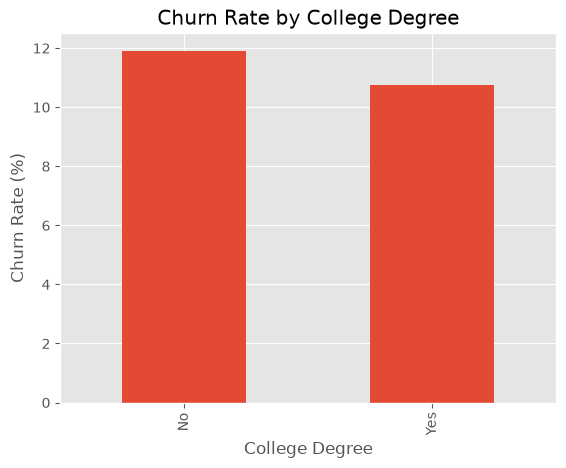

In [34]:
# Calculate and visualize the churn rate based on
# customers' educational background.

(
    df_clean
    .groupby("college_degree")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

(
    df_clean
    .groupby("college_degree")["Churn"]
    .mean()
    .mul(100)
    .plot(kind="bar")
)

plt.title("Churn Rate by College Degree")
plt.xlabel("College Degree")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

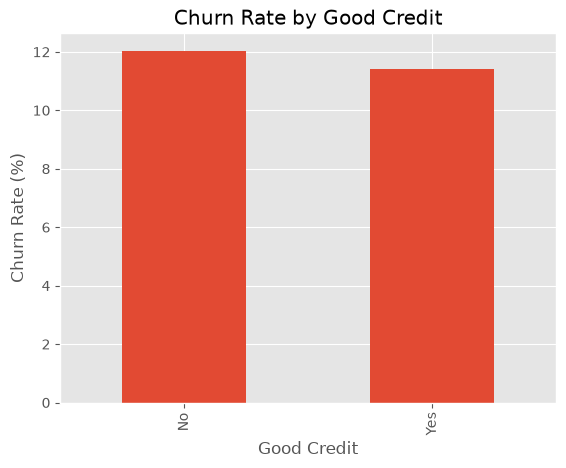

In [35]:
# Calculate and visualize the churn rate for customers
# with and without good credit history.

(
    df_clean
    .groupby("good_credit")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

(
    df_clean
    .groupby("good_credit")["Churn"]
    .mean()
    .mul(100)
    .plot(kind="bar")
)

plt.title("Churn Rate by Good Credit")
plt.xlabel("Good Credit")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()


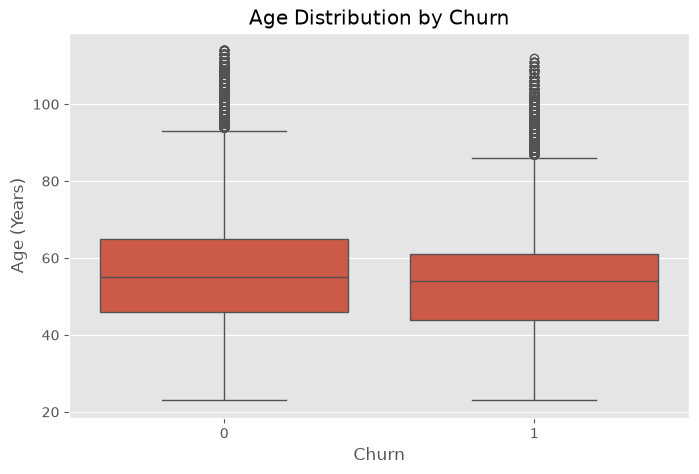

In [36]:
# Compare the distribution of customer age
# between churned and retained customers.
# Boxplots help identify differences in median,
# spread, and potential outliers.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="age_in_years"
)

plt.title("Age Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Age (Years)")

plt.show()


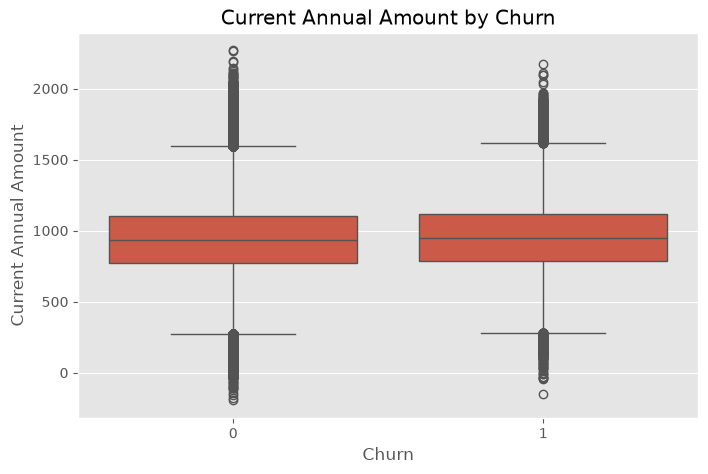

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="curr_ann_amt"
)

plt.title("Current Annual Amount by Churn")
plt.xlabel("Churn")
plt.ylabel("Current Annual Amount")

plt.show()


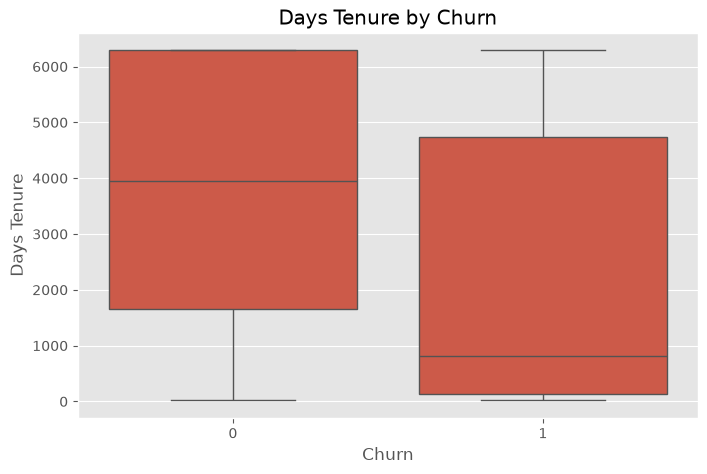

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="days_tenure"
)

plt.title("Days Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Days Tenure")

plt.show()


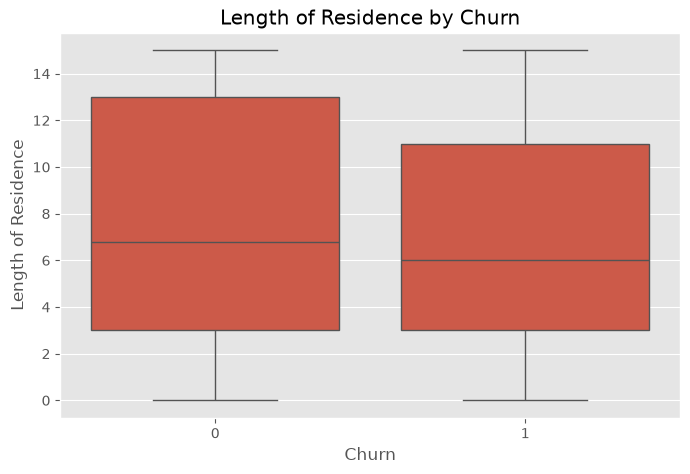

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="length_of_residence"
)

plt.title("Length of Residence by Churn")
plt.xlabel("Churn")
plt.ylabel("Length of Residence")

plt.show()

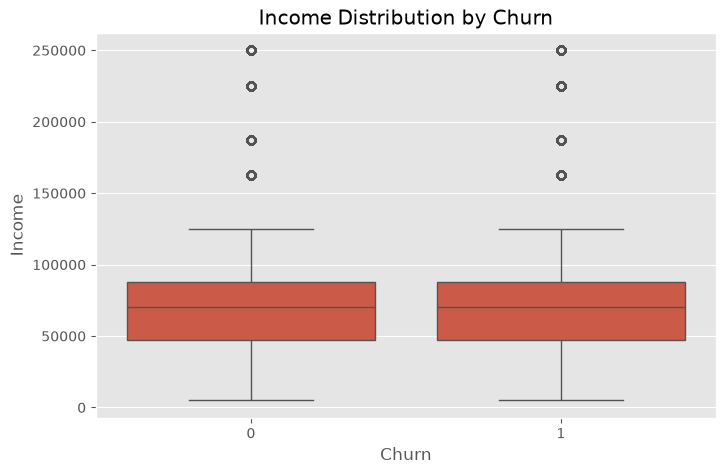

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="income"
)

plt.title("Income Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Income")

plt.show()


# Key Findings

## Data Quality
- No significant data quality issues were identified after preprocessing.
- The `state` feature contains only one unique value and provides no predictive information.

## Target Variable
- The dataset is highly imbalanced, with considerably more retained than churned customers.

## Numerical Features
- Numerical features show only weak linear correlations.
- `days_tenure` demonstrates the strongest relationship with customer churn.
- Age, income, and length of residence exhibit only minor differences between churned and retained customers.

## Categorical Features
- Categorical variables show varying churn rates across different customer groups.
- Some categorical features appear to contain useful predictive information.

## Next Steps
- Remove constant features.
- Encode categorical variables.
- Scale numerical features where required.
- Prepare the data for machine learning models.

In [41]:
import os

# Create the processed data directory if it does not exist
os.makedirs("../data/processed", exist_ok=True)

# Save the cleaned dataset
df_clean.to_csv("../data/processed/insurance_clean.csv", index=False)

print("Cleaned dataset successfully saved.")


Cleaned dataset successfully saved.
